# Regressão Softmax com dados do MNIST

## Objetivo

O objetivo deste notebook é ilustrar o uso de praticamente a mesma rede desenvolvida para a classificação das flores Íris, porém agora com o problema de classificação de dígitos manuscritos utilizando o dataset MNIST.
As principais diferenças são:
- tipo do dado, agora imagem com muito atributos: 28 x 28 pixels
- número de amostras, muito maior, 60 mil
Neste exercício será possível a interpretação do significado dos parâmetros treinados

## Importação das bibliotecas

In [1]:
# Instalação moderna do PyTorch
# Primeiro, desinstale versões antigas para evitar conflito
!pip uninstall -y torch torchvision torchaudio

# Instale versões compatíveis diretamente do índice oficial do PyTorch
# Para CPU:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu

# Se você tiver GPU CUDA disponível, troque "cpu" por "cu121" (CUDA 12.1), por exemplo:
# !pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

# Teste da instalação
import torch
import torchvision
import torchaudio

print("Torch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("Torchaudio:", torchaudio.__version__)
print("CUDA disponível:", torch.cuda.is_available())


Found existing installation: torch 2.8.0+cu126
Uninstalling torch-2.8.0+cu126:
  Successfully uninstalled torch-2.8.0+cu126
Found existing installation: torchvision 0.23.0+cu126
Uninstalling torchvision-0.23.0+cu126:
  Successfully uninstalled torchvision-0.23.0+cu126
Found existing installation: torchaudio 2.8.0+cu126
Uninstalling torchaudio-2.8.0+cu126:
  Successfully uninstalled torchaudio-2.8.0+cu126
Looking in indexes: https://download.pytorch.org/whl/cpu
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 184.4/184.4 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 495.6/495.6 kB 7.4 MB/s eta 0:00:00
Torch: 2.9.1+cpu
Torchvision: 0.24.1+cpu
Torchaudio: 2.9.1+cpu
CUDA disponível: False


In [2]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu


Looking in indexes: https://download.pytorch.org/whl/cpu


In [3]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import torch
from torch.autograd import Variable

import torchvision

## Carregamento dos dados do MNIST

In [4]:
! git clone https://github.com/vcasadei/MNIST.git

Cloning into 'MNIST'...
remote: Enumerating objects: 10, done.
remote: Total 10 (delta 0), reused 0 (delta 0), pack-reused 10 (from 1)
Receiving objects: 100% (10/10), 11.01 MiB | 9.39 MiB/s, done.
Resolving deltas: 100% (2/2), done.
Updating files: 100% (6/6), done.


In [5]:
!ls MNIST

processed  raw


In [6]:
dataset_dir = 'MNIST/'

x_train, y_train = torch.load(dataset_dir + 'processed/training.pt')

print("Amostras de treinamento:", x_train.size(0))

print("\nDimensões dos dados das imagens:   ", x_train.size())
print("Valores mínimo e máximo dos pixels:", torch.min(x_train), torch.max(x_train))
print("Tipo dos dados das imagens:        ", type(x_train))
print("Tipo das classes das imagens:      ", type(y_train))

Amostras de treinamento: 60000

Dimensões dos dados das imagens:    torch.Size([60000, 28, 28])
Valores mínimo e máximo dos pixels: tensor(0, dtype=torch.uint8) tensor(255, dtype=torch.uint8)
Tipo dos dados das imagens:         <class 'torch.Tensor'>
Tipo das classes das imagens:       <class 'torch.Tensor'>


### Carregamento, normalização e seleção dos dados do MNIST

Neste exemplo utilizaremos apenas 1000 amostras de treinamento.

In [7]:
x_train = x_train.float()

x_train = x_train / 255.

if True:
    n_samples_train = 1000

    x_train = x_train[:n_samples_train]
    y_train = y_train[:n_samples_train]

print("Amostras de treinamento:", x_train.size(0))

print("\nDimensões dos dados das imagens:   ", x_train.size())
print("Valores mínimo e máximo dos pixels:", torch.min(x_train), torch.max(x_train))
print("Tipo dos dados das imagens:        ", type(x_train))
print("Tipo das classes das imagens:      ", type(y_train))

Amostras de treinamento: 1000

Dimensões dos dados das imagens:    torch.Size([1000, 28, 28])
Valores mínimo e máximo dos pixels: tensor(0.) tensor(1.)
Tipo dos dados das imagens:         <class 'torch.Tensor'>
Tipo das classes das imagens:       <class 'torch.Tensor'>


### Visualizando os dados

(np.float64(-0.5), np.float64(232.5), np.float64(87.5), np.float64(-0.5))

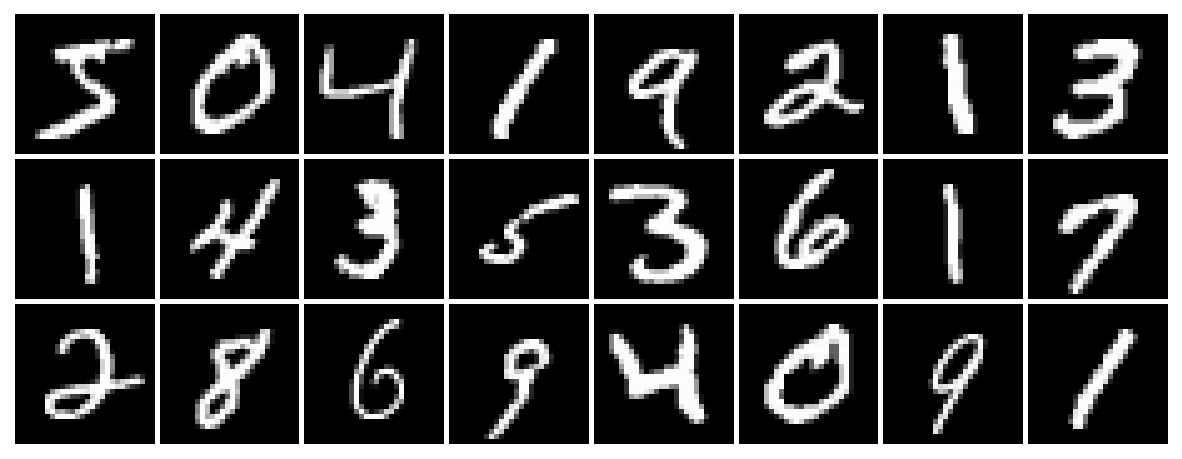

In [8]:
n_samples = 24

# cria um grid com as imagens
grid = torchvision.utils.make_grid(x_train[:n_samples].unsqueeze(dim=1), pad_value=1.0, padding=1)

plt.figure(figsize=(15, 10))
plt.imshow(grid.numpy().transpose(1, 2, 0))
plt.axis('off')

### Visualizando uma imagem com o matplotlib

class: tensor(5)


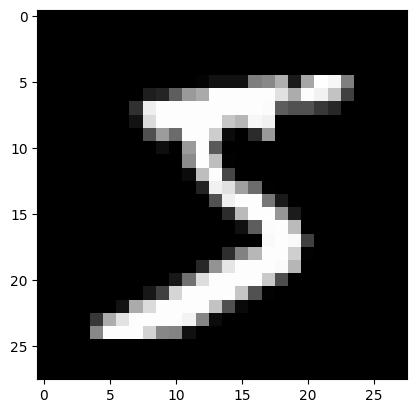

In [9]:
image  = x_train[0]
target = y_train[0]

plt.imshow(image.numpy(), cmap='gray')
print('class:', target)

## Modelo

In [10]:
model = torch.nn.Linear(28*28, 10) # 28*28 atributos de entrada e 10 neurônios na sáida

### Testando um predict com poucas amostras

In [11]:
xin = x_train[:5].view(-1,28*28)
score = model(Variable(xin))
score

tensor([[-5.5748e-02, -1.0373e-01, -5.5677e-01,  1.9713e-01,  1.7633e-01,
          6.0000e-02, -2.0532e-02,  1.0795e-01, -1.3246e-01, -1.2101e-01],
        [-1.8991e-01,  2.1656e-01, -4.7255e-02,  7.4370e-02,  4.7164e-01,
          2.1062e-01, -1.9539e-02,  7.6341e-02,  2.3438e-01,  5.2937e-02],
        [ 3.0415e-01, -7.3431e-02,  5.9366e-02, -2.9898e-03,  1.6766e-01,
          1.2134e-02,  2.6957e-01,  3.9664e-02, -1.9666e-01, -8.7103e-02],
        [-1.9690e-01,  6.8121e-02, -4.1045e-02,  1.1943e-01,  9.1696e-02,
          3.1463e-02,  4.2401e-01, -2.7710e-02, -2.0595e-04, -2.3975e-01],
        [-1.7222e-01, -5.2247e-02,  1.5807e-01, -1.3900e-03,  4.3456e-01,
         -7.8859e-02,  1.9759e-01, -6.3635e-02, -1.2260e-01,  4.3185e-02]],
       grad_fn=<AddmmBackward0>)

## Treinamento

### Inicialização dos parâmetros

In [12]:
epochs = 100
learningRate = 0.5

# Utilizaremos CrossEntropyLoss como função de perda
criterion = torch.nn.CrossEntropyLoss()

# Gradiente descendente
optimizer = torch.optim.SGD(model.parameters(), lr=learningRate)

### Visualização do grafo computacional da perda (loss)

In [13]:
!pip install graphviz
!pip install git+https://github.com/szagoruyko/pytorchviz

  Cloning https://github.com/szagoruyko/pytorchviz to /tmp/pip-req-build-yxqp1v5s
  Running command git clone --filter=blob:none --quiet https://github.com/szagoruyko/pytorchviz /tmp/pip-req-build-yxqp1v5s
  Resolved https://github.com/szagoruyko/pytorchviz to commit 5cf04c13e601366f6b9cf5939b5af5144d55b887
  Preparing metadata (setup.py) ... done
  Created wheel for torchviz: filename=torchviz-0.0.2-py3-none-any.whl size=4972 sha256=3700dc0d70df0011877c936380634f5376efa37858f9413b142fd62af820a4cc
  Stored in directory: /tmp/pip-ephem-wheel-cache-y_b2wyyz/wheels/8a/88/98/69bcb99aba99a6bba9b2b81439cbda0101df40c49e639c4216
Successfully built torchviz


In [14]:
from torchviz import make_dot, make_dot_from_trace
y_pred = model(Variable(x_train.view(-1,28*28)))
loss = criterion(y_pred, Variable(y_train))
loss
# p = make_dot(loss, dict(model.named_parameters()))
# p

tensor(2.3047, grad_fn=<NllLossBackward0>)

### Laço de treinamento dos pesos

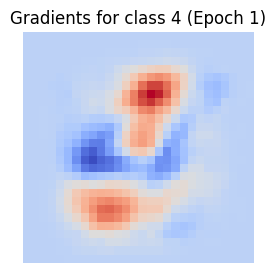

Epoch[1/100], loss: 2.304733, acc: 0.089000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


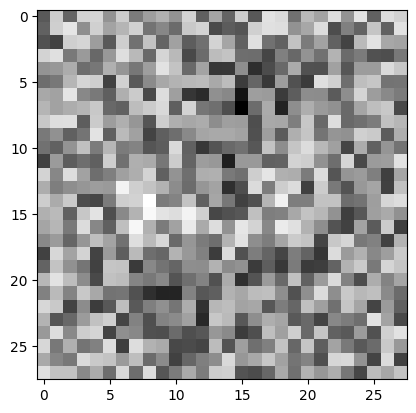

Epoch[2/100], loss: 1.800213, acc: 0.595000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


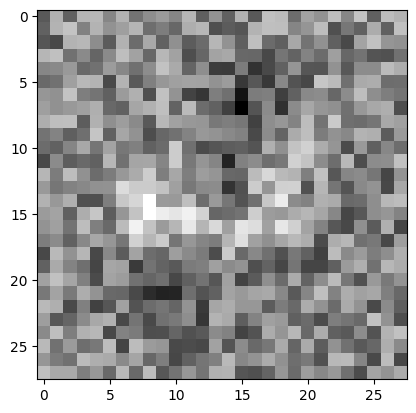

Epoch[3/100], loss: 1.467655, acc: 0.768000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


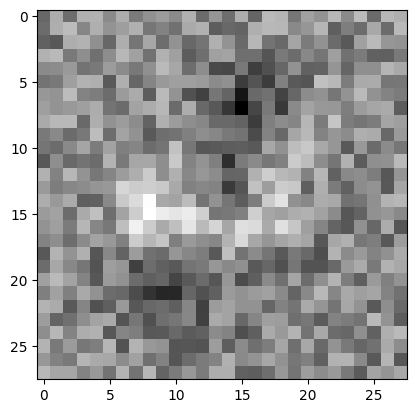

Epoch[4/100], loss: 1.244759, acc: 0.771000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


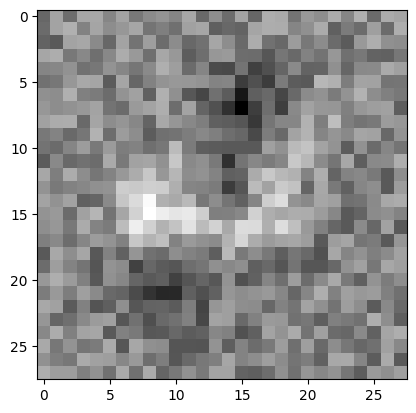

Epoch[5/100], loss: 1.095023, acc: 0.802000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


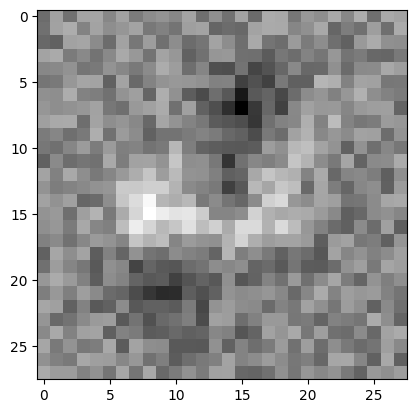

Epoch[6/100], loss: 0.984801, acc: 0.818000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


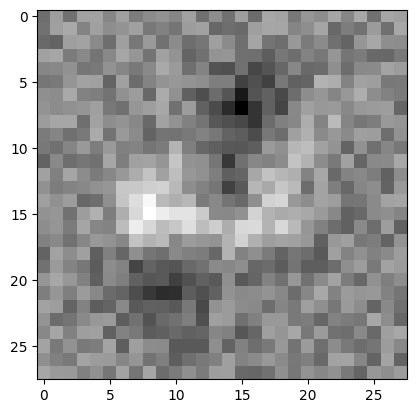

Epoch[7/100], loss: 0.904388, acc: 0.830000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


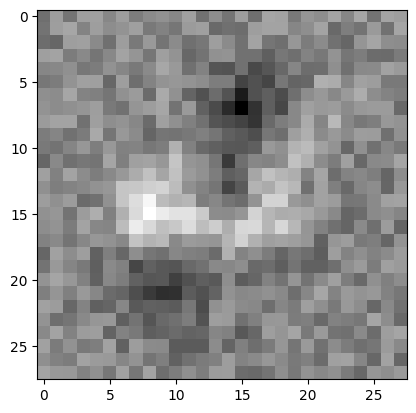

Epoch[8/100], loss: 0.842511, acc: 0.835000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


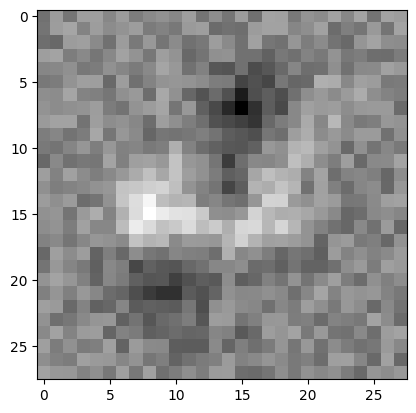

Epoch[9/100], loss: 0.793088, acc: 0.846000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


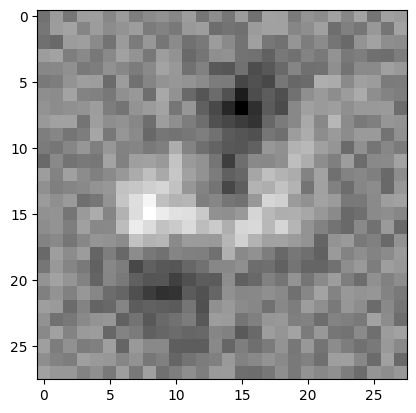

Epoch[10/100], loss: 0.752355, acc: 0.851000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


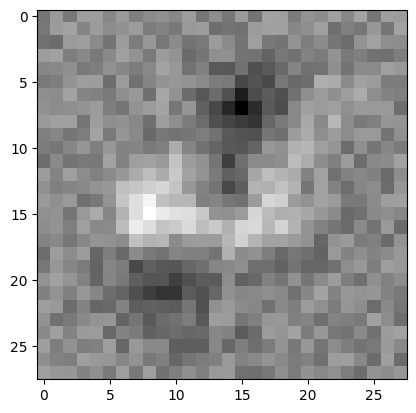

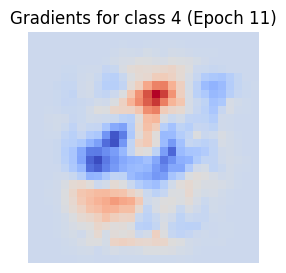

Epoch[11/100], loss: 0.718008, acc: 0.854000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


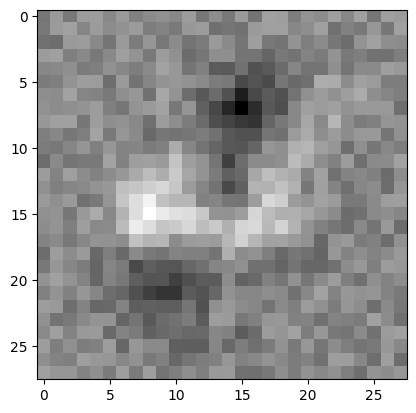

Epoch[12/100], loss: 0.688535, acc: 0.860000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


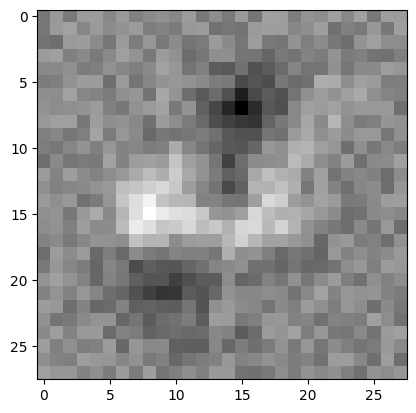

Epoch[13/100], loss: 0.662880, acc: 0.867000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


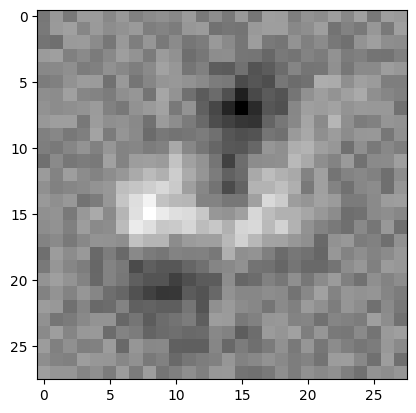

Epoch[14/100], loss: 0.640280, acc: 0.868000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


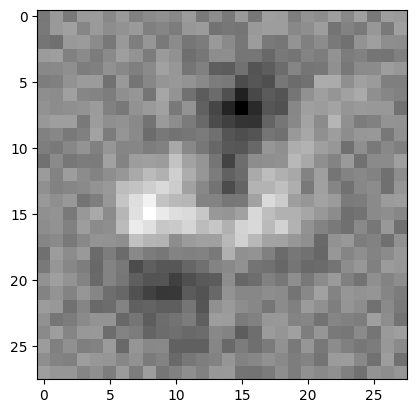

Epoch[15/100], loss: 0.620168, acc: 0.869000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


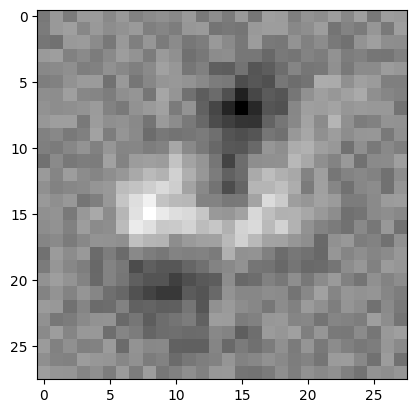

Epoch[16/100], loss: 0.602110, acc: 0.871000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


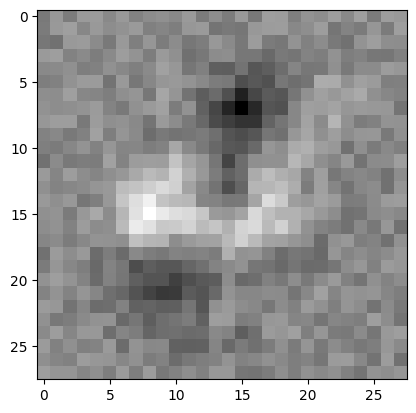

Epoch[17/100], loss: 0.585774, acc: 0.872000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


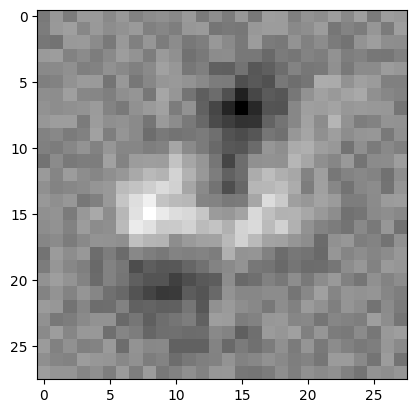

Epoch[18/100], loss: 0.570896, acc: 0.875000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


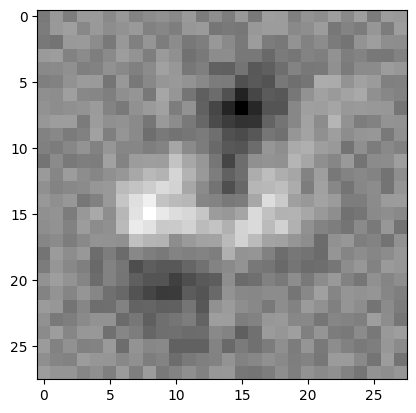

Epoch[19/100], loss: 0.557264, acc: 0.880000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


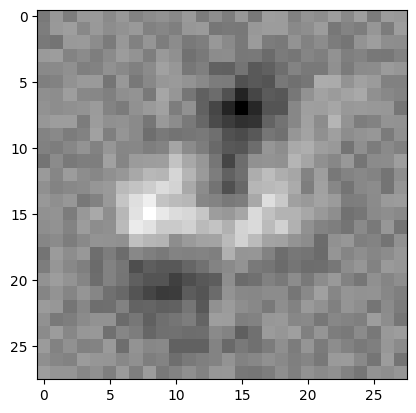

Epoch[20/100], loss: 0.544710, acc: 0.882000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


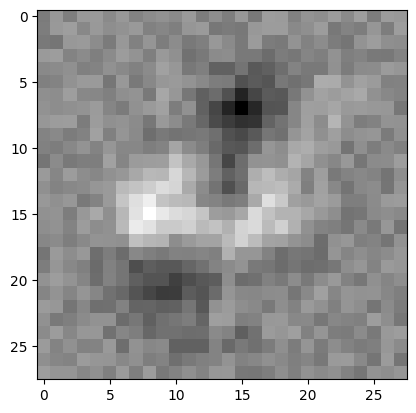

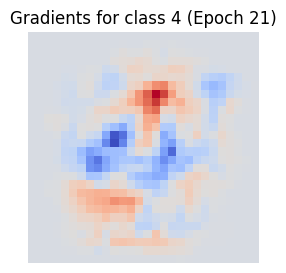

Epoch[21/100], loss: 0.533093, acc: 0.884000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


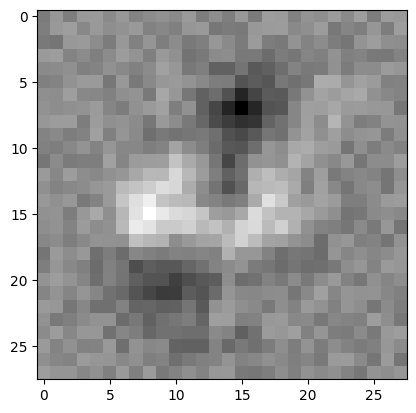

Epoch[22/100], loss: 0.522298, acc: 0.886000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


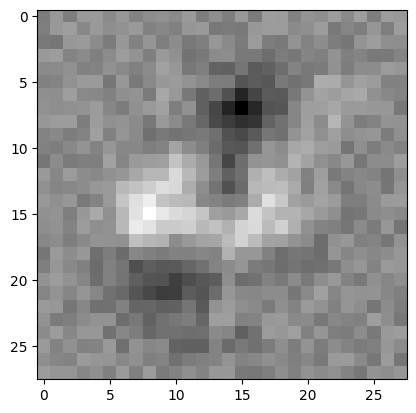

Epoch[23/100], loss: 0.512228, acc: 0.887000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


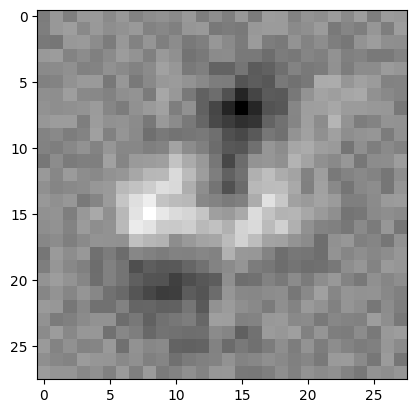

Epoch[24/100], loss: 0.502802, acc: 0.887000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


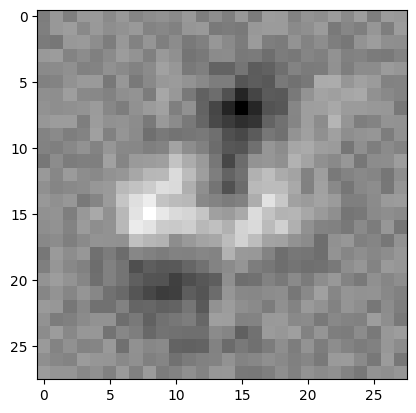

Epoch[25/100], loss: 0.493950, acc: 0.889000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


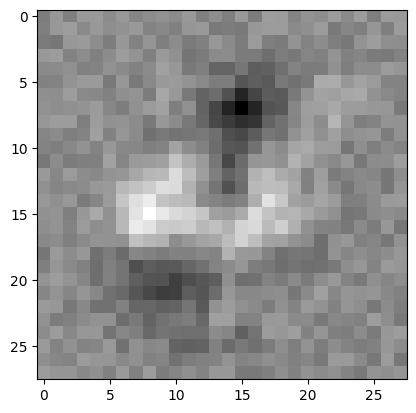

Epoch[26/100], loss: 0.485614, acc: 0.890000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


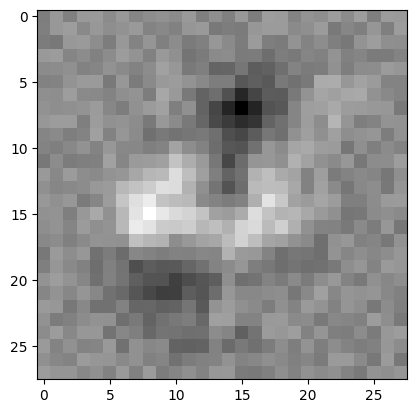

Epoch[27/100], loss: 0.477742, acc: 0.896000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


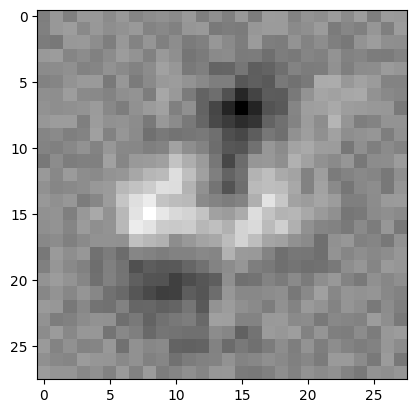

Epoch[28/100], loss: 0.470291, acc: 0.897000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


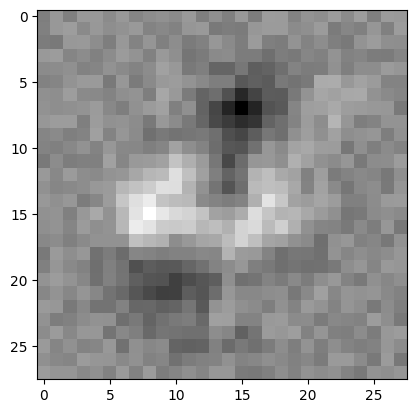

Epoch[29/100], loss: 0.463221, acc: 0.899000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


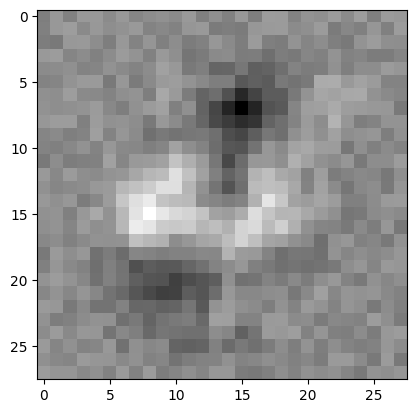

Epoch[30/100], loss: 0.456500, acc: 0.899000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


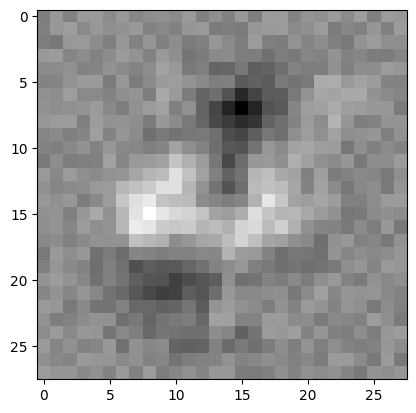

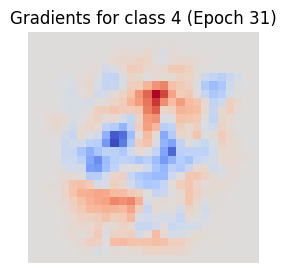

Epoch[31/100], loss: 0.450098, acc: 0.899000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


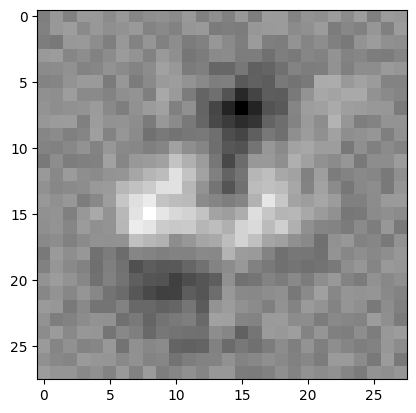

Epoch[32/100], loss: 0.443988, acc: 0.899000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


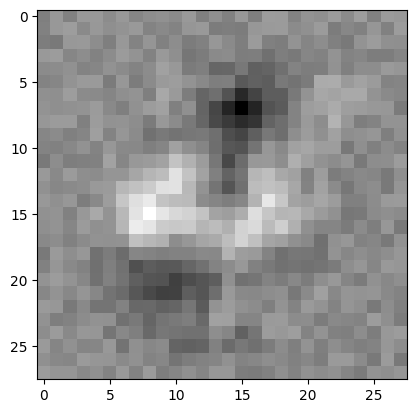

Epoch[33/100], loss: 0.438147, acc: 0.899000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


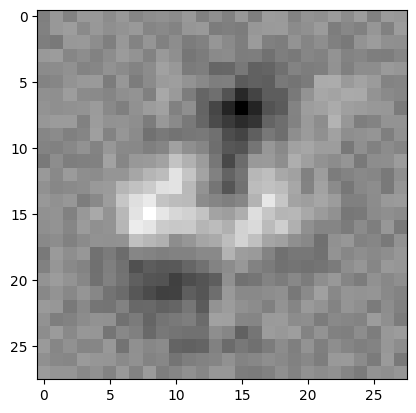

Epoch[34/100], loss: 0.432554, acc: 0.901000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


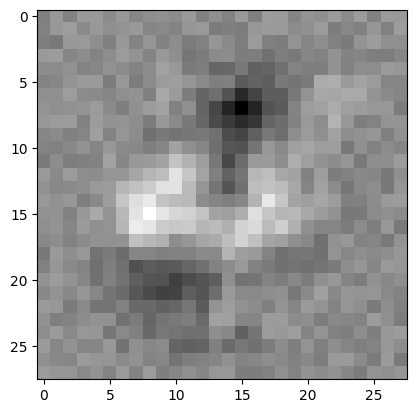

Epoch[35/100], loss: 0.427191, acc: 0.901000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


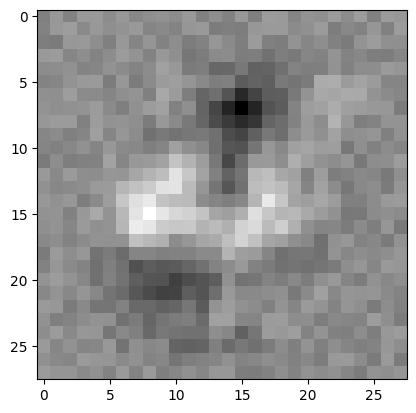

Epoch[36/100], loss: 0.422042, acc: 0.902000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


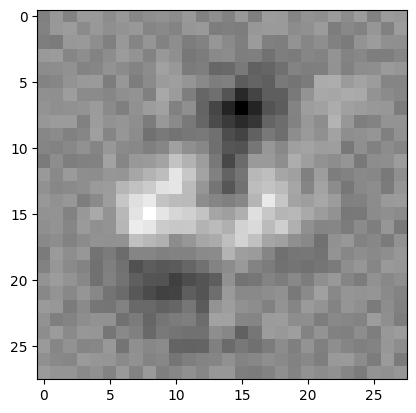

Epoch[37/100], loss: 0.417091, acc: 0.902000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


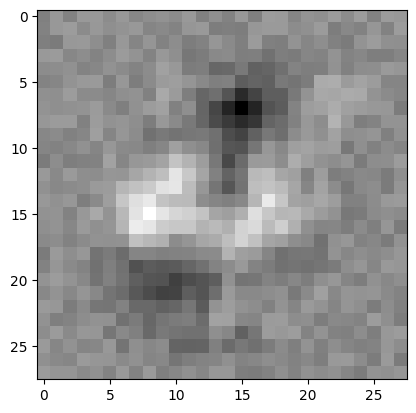

Epoch[38/100], loss: 0.412324, acc: 0.904000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


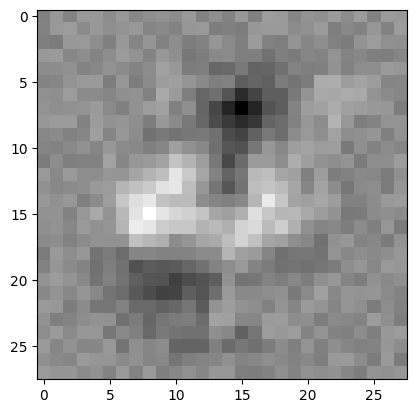

Epoch[39/100], loss: 0.407730, acc: 0.905000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


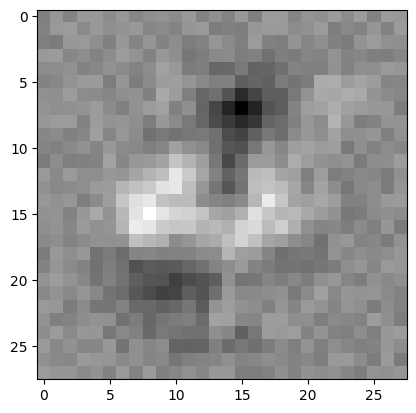

Epoch[40/100], loss: 0.403297, acc: 0.907000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


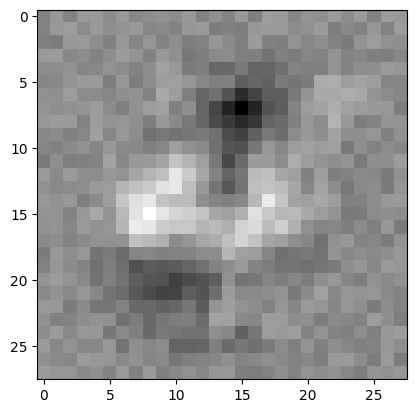

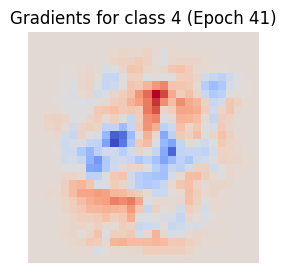

Epoch[41/100], loss: 0.399015, acc: 0.910000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


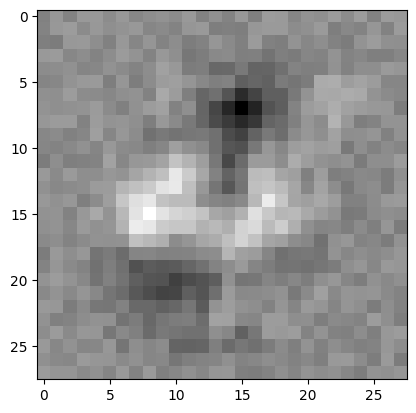

Epoch[42/100], loss: 0.394875, acc: 0.912000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


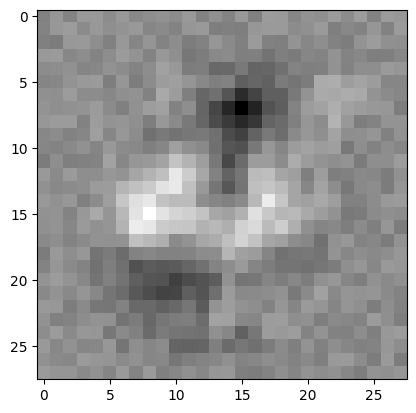

Epoch[43/100], loss: 0.390868, acc: 0.914000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


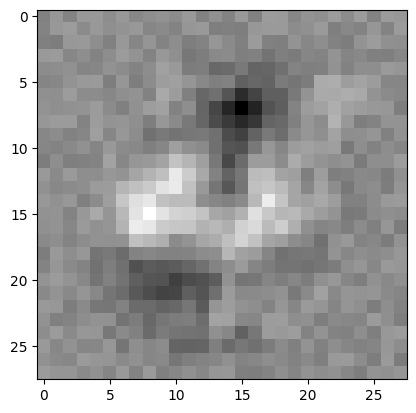

Epoch[44/100], loss: 0.386988, acc: 0.914000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


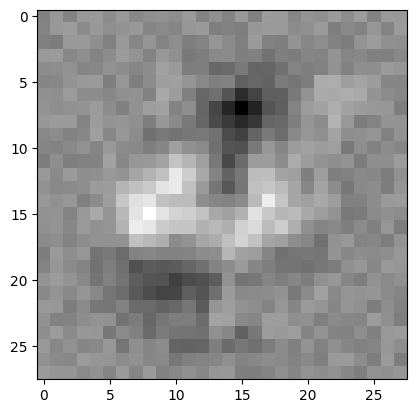

Epoch[45/100], loss: 0.383225, acc: 0.915000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


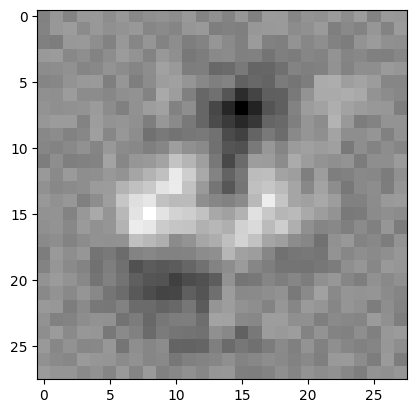

Epoch[46/100], loss: 0.379575, acc: 0.915000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


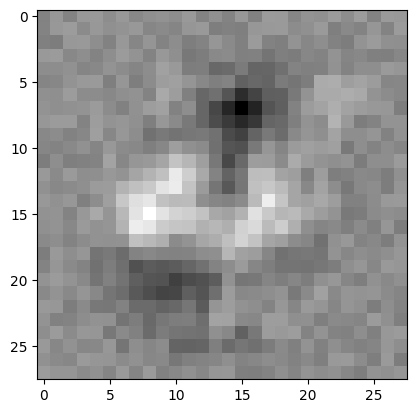

Epoch[47/100], loss: 0.376030, acc: 0.918000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


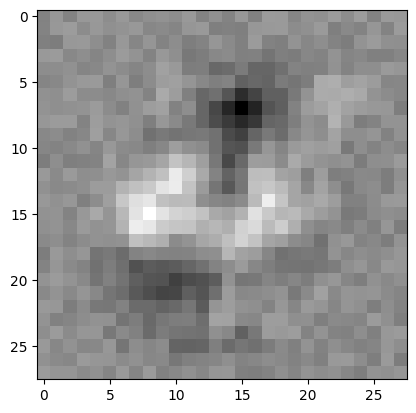

Epoch[48/100], loss: 0.372586, acc: 0.918000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


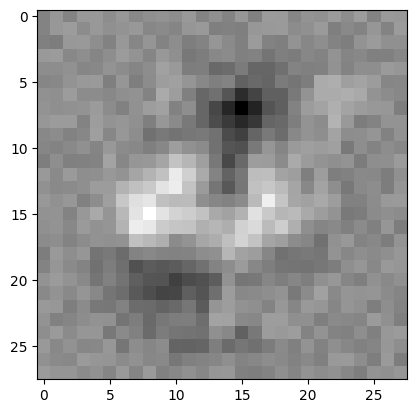

Epoch[49/100], loss: 0.369236, acc: 0.920000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


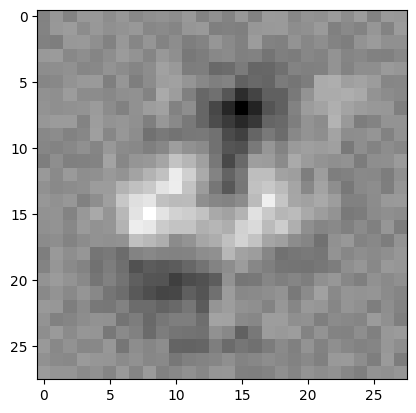

Epoch[50/100], loss: 0.365977, acc: 0.922000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


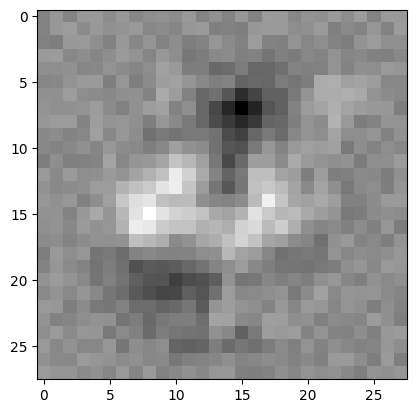

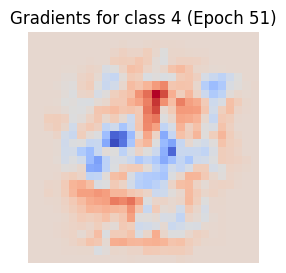

Epoch[51/100], loss: 0.362804, acc: 0.922000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


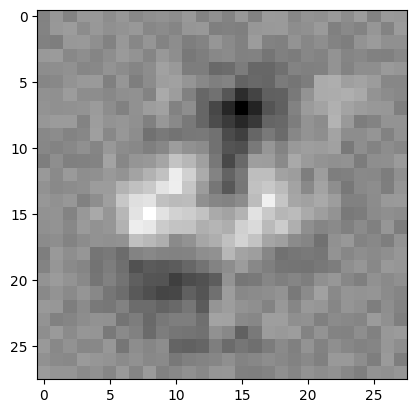

Epoch[52/100], loss: 0.359712, acc: 0.923000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


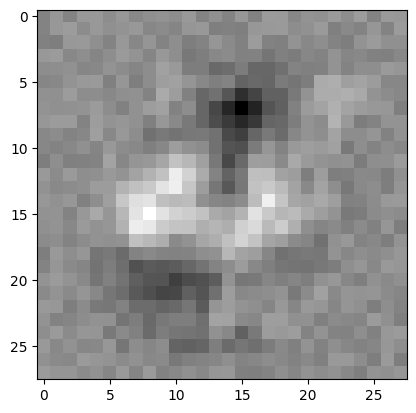

Epoch[53/100], loss: 0.356698, acc: 0.924000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


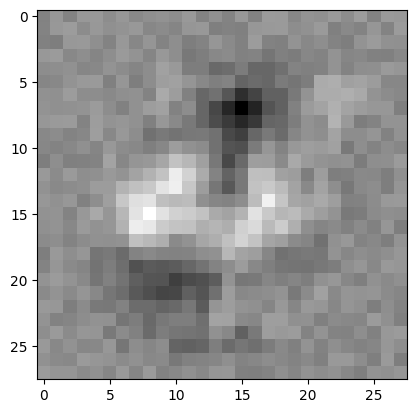

Epoch[54/100], loss: 0.353758, acc: 0.926000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


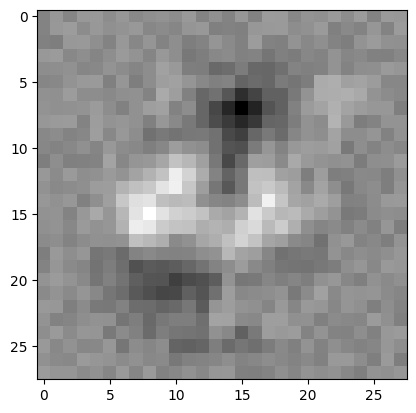

Epoch[55/100], loss: 0.350889, acc: 0.927000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


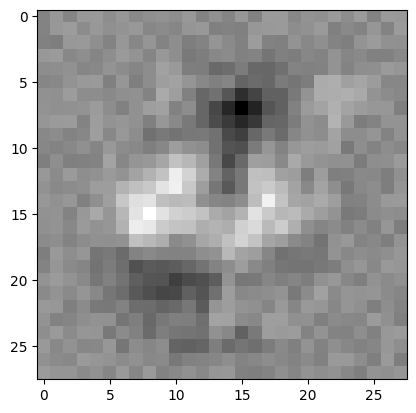

Epoch[56/100], loss: 0.348087, acc: 0.927000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


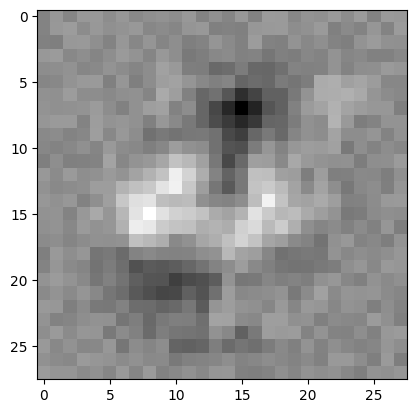

Epoch[57/100], loss: 0.345350, acc: 0.927000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


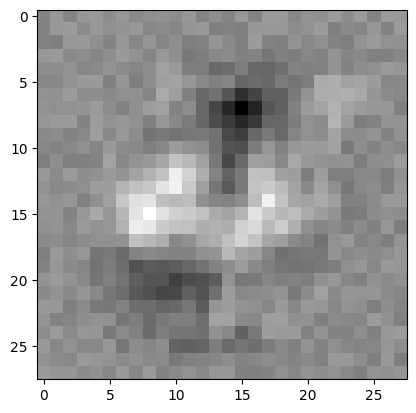

Epoch[58/100], loss: 0.342675, acc: 0.927000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


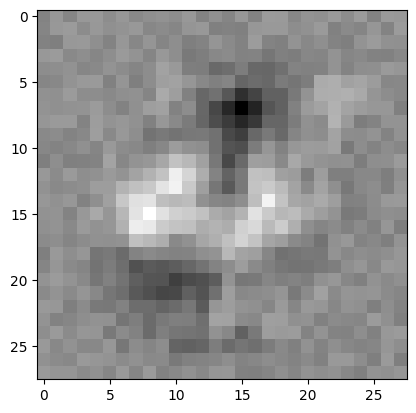

Epoch[59/100], loss: 0.340059, acc: 0.927000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


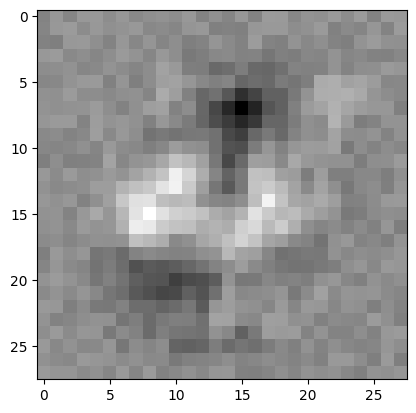

Epoch[60/100], loss: 0.337500, acc: 0.928000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


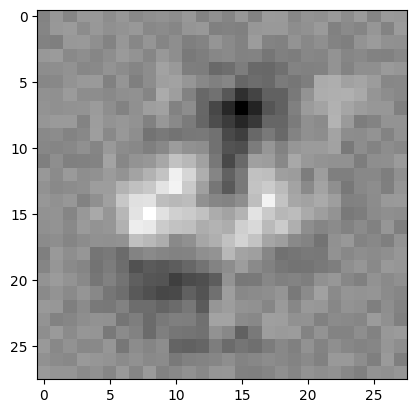

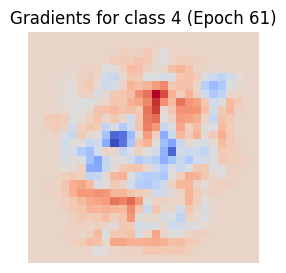

Epoch[61/100], loss: 0.334996, acc: 0.928000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


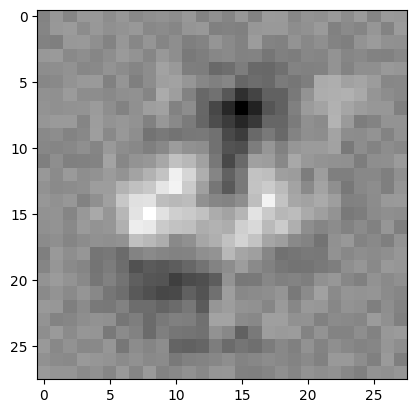

Epoch[62/100], loss: 0.332543, acc: 0.929000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


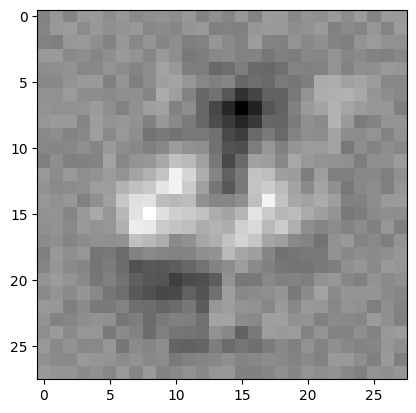

Epoch[63/100], loss: 0.330141, acc: 0.928000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


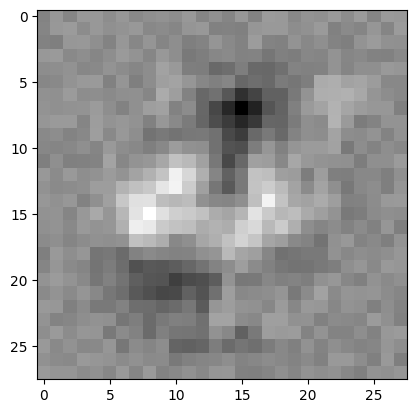

Epoch[64/100], loss: 0.327788, acc: 0.928000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


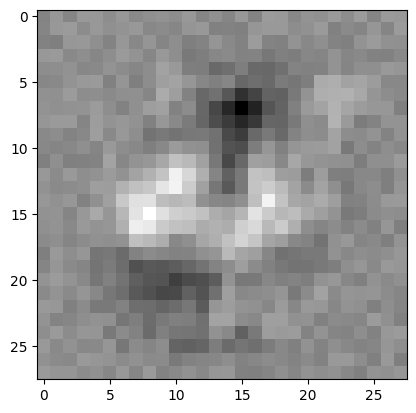

Epoch[65/100], loss: 0.325480, acc: 0.928000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


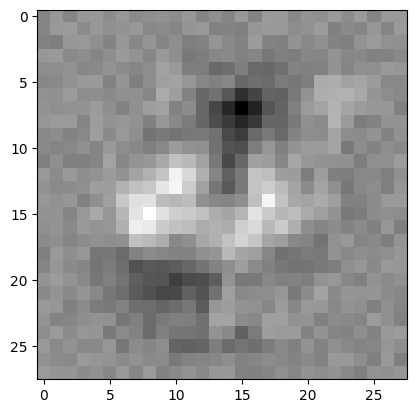

Epoch[66/100], loss: 0.323218, acc: 0.928000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


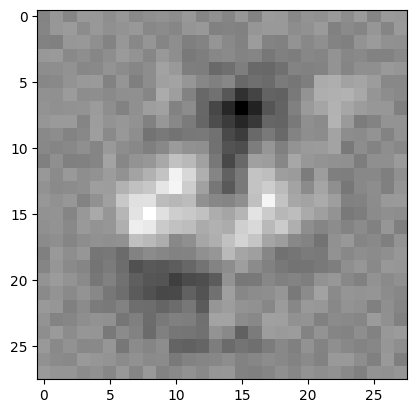

Epoch[67/100], loss: 0.320998, acc: 0.928000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


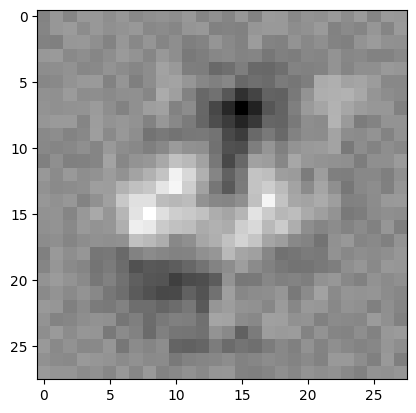

Epoch[68/100], loss: 0.318821, acc: 0.928000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


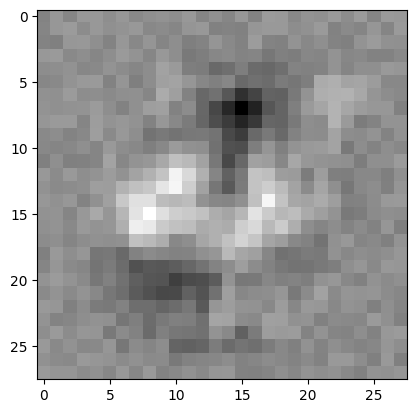

Epoch[69/100], loss: 0.316683, acc: 0.928000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


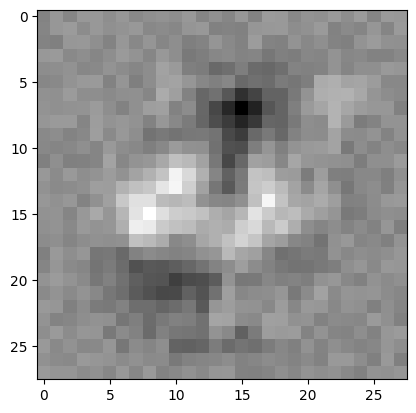

Epoch[70/100], loss: 0.314584, acc: 0.928000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


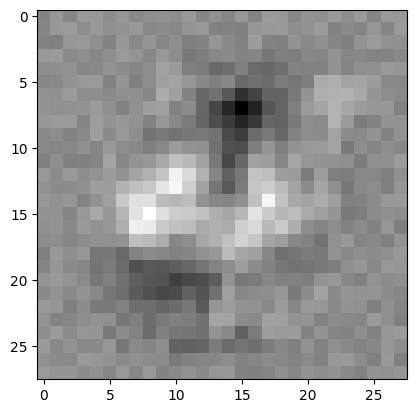

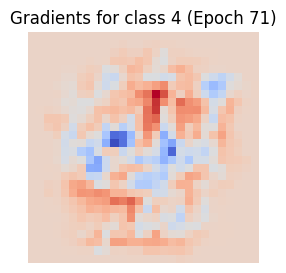

Epoch[71/100], loss: 0.312523, acc: 0.929000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


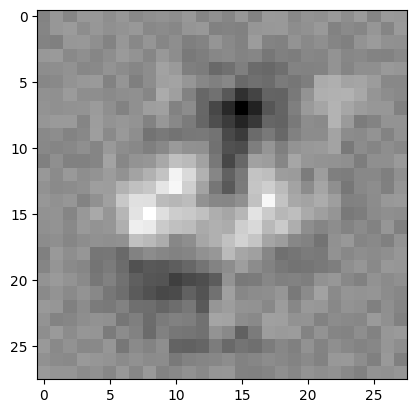

Epoch[72/100], loss: 0.310498, acc: 0.930000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


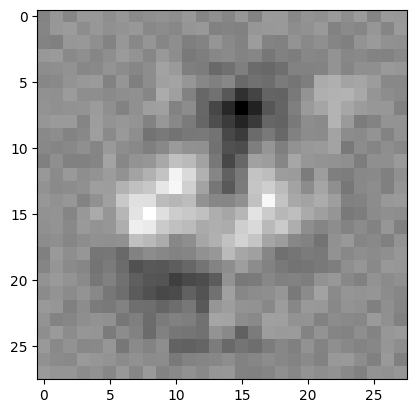

Epoch[73/100], loss: 0.308507, acc: 0.930000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


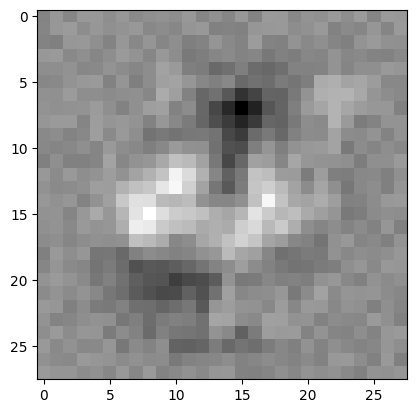

Epoch[74/100], loss: 0.306551, acc: 0.931000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


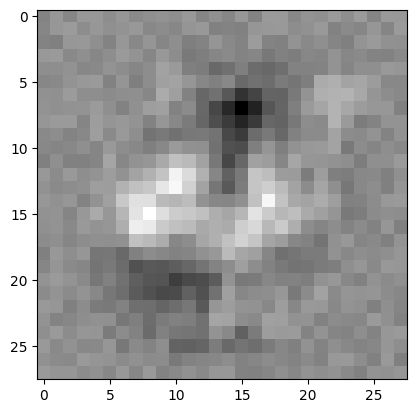

Epoch[75/100], loss: 0.304627, acc: 0.931000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


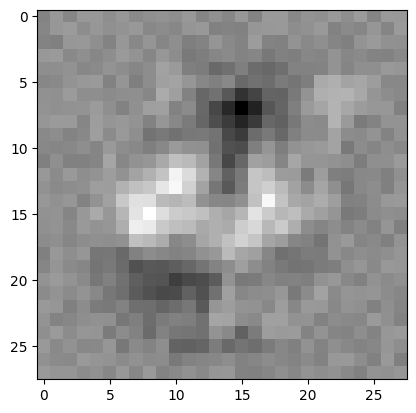

Epoch[76/100], loss: 0.302735, acc: 0.931000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


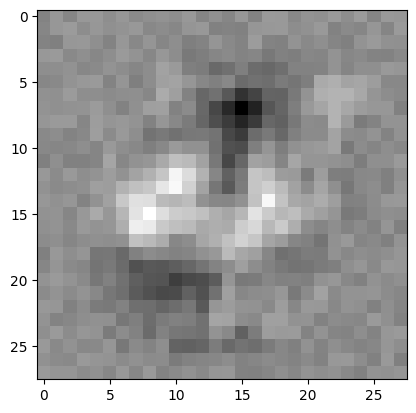

Epoch[77/100], loss: 0.300874, acc: 0.931000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


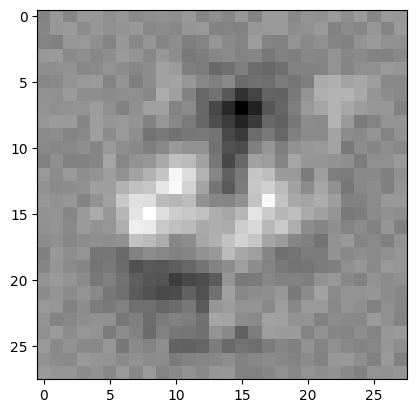

Epoch[78/100], loss: 0.299042, acc: 0.933000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


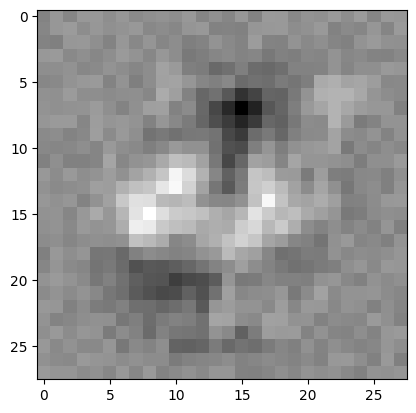

Epoch[79/100], loss: 0.297239, acc: 0.934000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


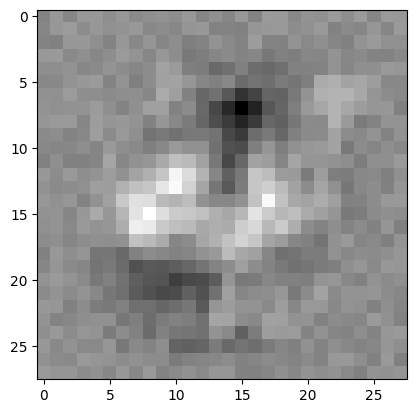

Epoch[80/100], loss: 0.295465, acc: 0.935000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


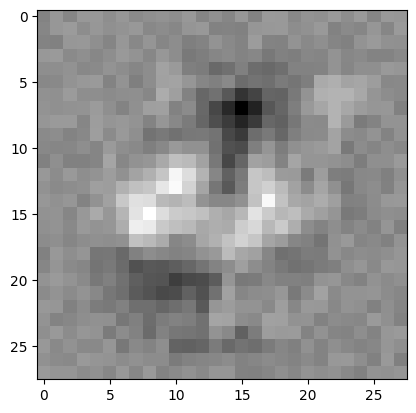

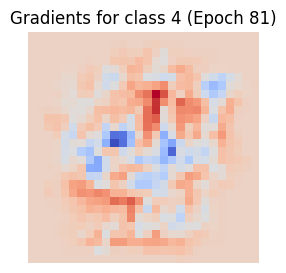

Epoch[81/100], loss: 0.293717, acc: 0.935000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


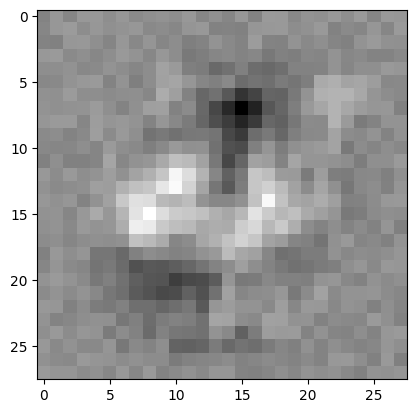

Epoch[82/100], loss: 0.291996, acc: 0.935000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


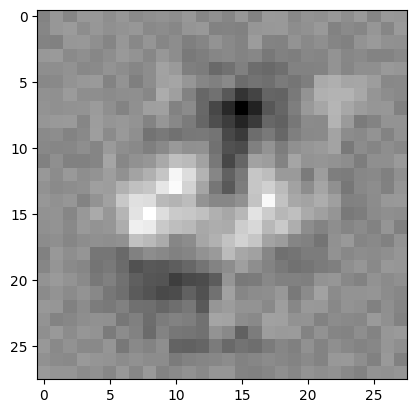

Epoch[83/100], loss: 0.290301, acc: 0.935000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


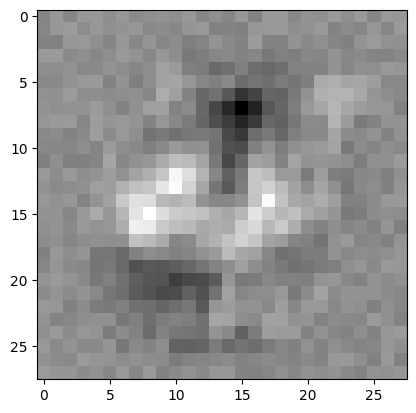

Epoch[84/100], loss: 0.288630, acc: 0.937000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


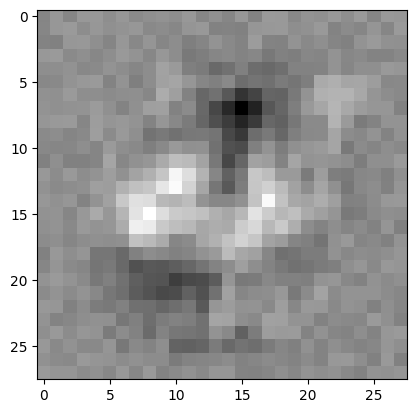

Epoch[85/100], loss: 0.286984, acc: 0.938000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


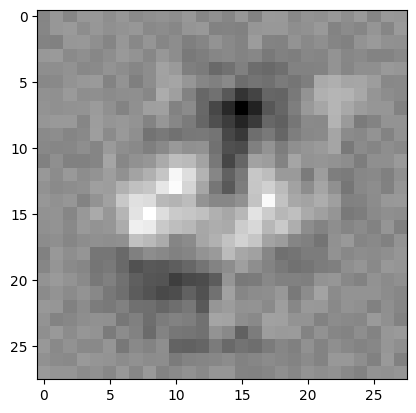

Epoch[86/100], loss: 0.285361, acc: 0.938000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


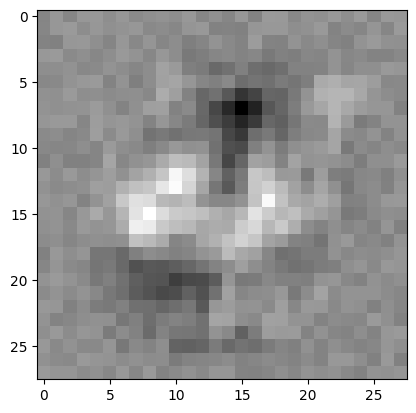

Epoch[87/100], loss: 0.283761, acc: 0.938000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


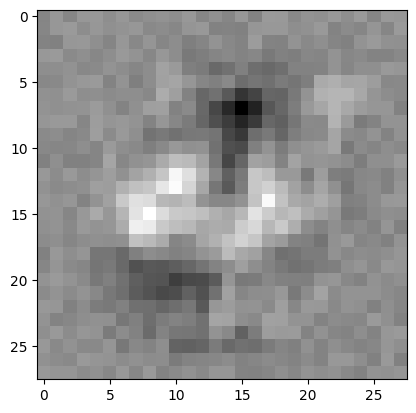

Epoch[88/100], loss: 0.282184, acc: 0.938000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


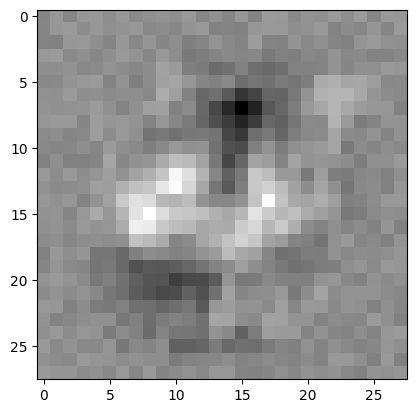

Epoch[89/100], loss: 0.280628, acc: 0.938000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


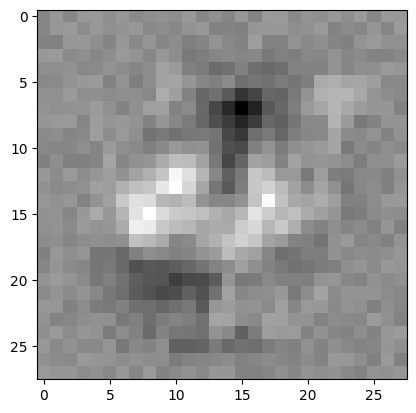

Epoch[90/100], loss: 0.279094, acc: 0.939000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


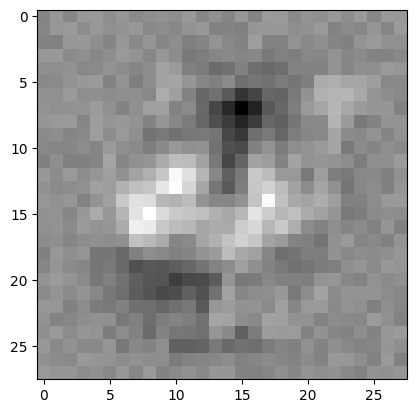

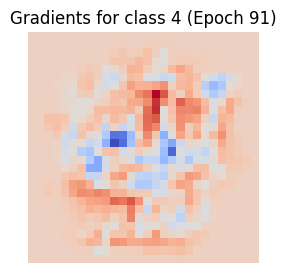

Epoch[91/100], loss: 0.277580, acc: 0.940000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


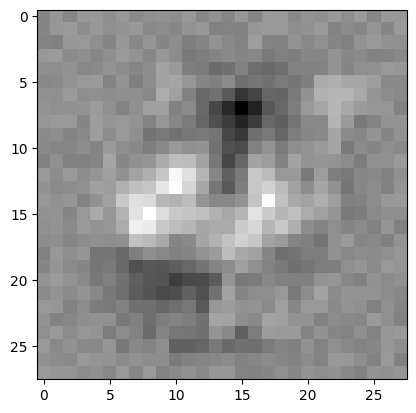

Epoch[92/100], loss: 0.276086, acc: 0.941000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


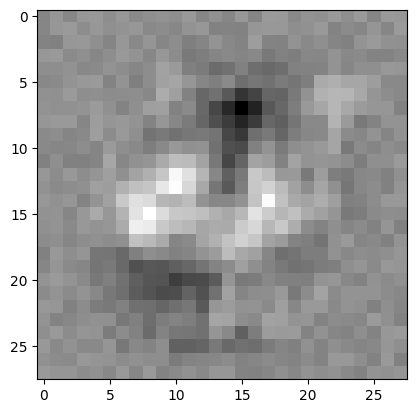

Epoch[93/100], loss: 0.274612, acc: 0.941000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


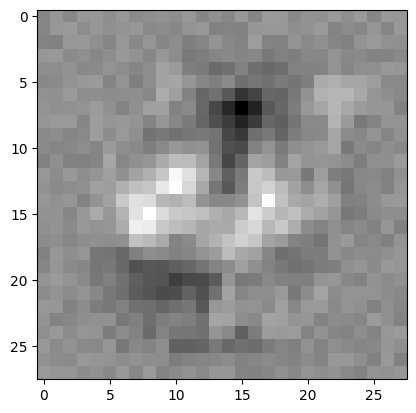

Epoch[94/100], loss: 0.273157, acc: 0.941000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


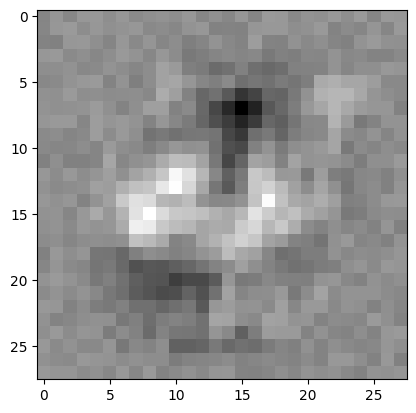

Epoch[95/100], loss: 0.271721, acc: 0.941000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


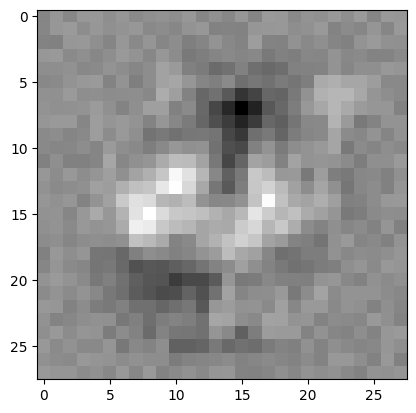

Epoch[96/100], loss: 0.270303, acc: 0.941000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


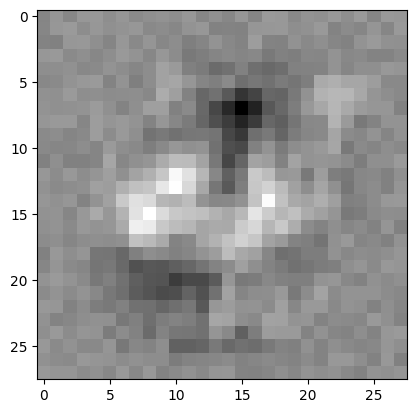

Epoch[97/100], loss: 0.268902, acc: 0.941000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


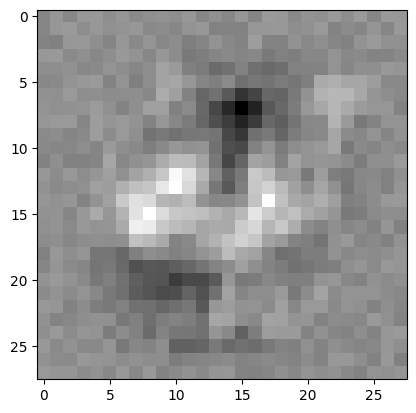

Epoch[98/100], loss: 0.267519, acc: 0.941000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


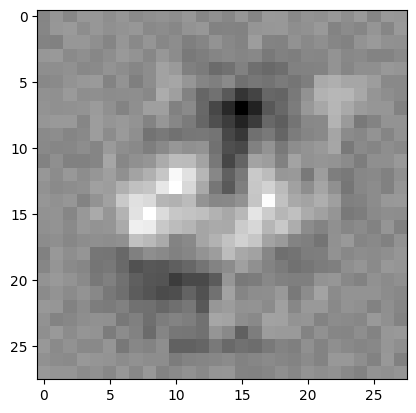

Epoch[99/100], loss: 0.266153, acc: 0.941000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


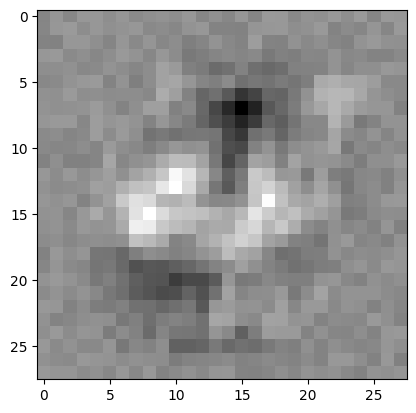

Epoch[100/100], loss: 0.264804, acc: 0.942000
weights: torch.Size([10, 784])
bias:    torch.Size([10])


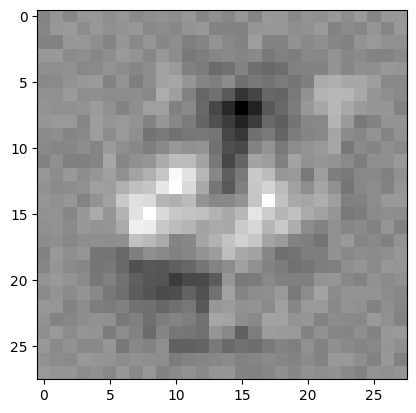

In [15]:
losses = []
zs = []

for i in range(epochs):
    # Transforma a entrada para uma dimensão
    inputs = x_train.view(-1, 28 * 28)
    # Predict da rede
    outputs = model(inputs)

    # exemplo: salvar os logits da classe 1 para todo o batch
    zs.append(outputs[:, 1].detach().numpy())

    # calcula a perda
    loss = criterion(outputs, y_train)

    # zero, backpropagation, ajusta parâmetros pelo gradiente descendente
    optimizer.zero_grad()
    loss.backward()

    # --- Exercício 3: Visualização dos gradientes da classe 4 ---
    if i % 10 == 0: # Visualize gradients every 10 epochs for clarity
        # Certifique-se de que os gradientes foram calculados
        # Access gradients directly from the model's parameters
        if model.weight.grad is not None:
            # Gradientes para a classe 4 (índice 4)
            gradients_class_4 = model.weight.grad[4, :].cpu().numpy()
            plt.figure(figsize=(3, 3))
            plt.imshow(gradients_class_4.reshape((28, 28)), cmap='coolwarm')
            plt.title(f'Gradients for class 4 (Epoch {i+1})')
            plt.axis('off')
            plt.show()
        else:
            print(f'Gradients for weights not available at Epoch {i+1}')
    # -----------------------------------------------------------

    optimizer.step()

    losses.append(loss.item())

    _, predicts = torch.max(outputs, 1)

    y_pred = predicts.detach().numpy()
    accuracy = (y_pred == y_train.detach().numpy()).mean()

    print('Epoch[{}/{}], loss: {:.6f}, acc: {:.6f}'
          .format(i+1, epochs, loss.item(), accuracy))

    weights = model.state_dict()['weight']
    print('weights:', weights.shape)

    bias = model.state_dict()['bias']
    print('bias:   ', bias.shape)

    # Visualizando pesos da classe 3 (índice 4)
    plt.imshow(weights[4, :].detach().numpy().reshape((28,28)), cmap='gray')
    plt.show()

In [16]:
print('Final loss:', loss.item())

Final loss: 0.2648038864135742


### Visualizando gráfico de perda durante o treinamento

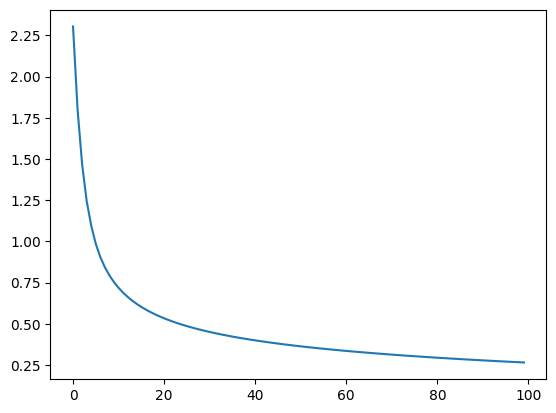

In [17]:
plt.plot(losses)

## Avaliação

### Acurácia tanto no conjunto de treinamento como no conjunto de testes

In [18]:
def predict(model, input_data):
    outputs = model(Variable(input_data))
    _, predicts = torch.max(outputs, 1)

    return predicts.data

y_pred = predict(model, x_train.view(-1, 28*28))
accuracy = (y_pred.numpy() == y_train.numpy()).mean()
print('Accuracy:', accuracy)

Accuracy: 0.943


### Matriz de confusão com dados de treinamento e teste

In [19]:
print('Matriz de confusão:')
pd.crosstab(y_pred.numpy(), y_train.numpy())

Matriz de confusão:


col_0,0,1,2,3,4,5,6,7,8,9
row_0,,,,,,,,,,
0,96,0,1,0,0,0,1,0,0,2
1,0,110,1,0,0,0,2,3,1,0
2,0,1,91,1,0,1,0,1,1,1
3,0,0,0,88,0,2,0,0,0,0
4,0,0,1,0,102,2,0,2,0,3
5,0,2,0,1,0,82,0,0,1,1
6,1,0,1,1,2,2,91,0,1,0
7,0,1,1,1,0,0,0,110,0,3
8,0,2,2,0,0,1,0,0,83,0


## Visualizando a matriz de pesos treinados

Observe que a matriz de peso treinado para cada classe mostra a importância dos pesos associados aos caracteres de cada classe.

weights: torch.Size([10, 784])
bias:    torch.Size([10])


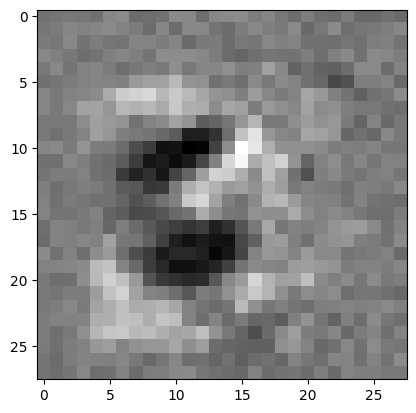

In [20]:
weights = model.state_dict()['weight']
print('weights:', weights.shape)

bias = model.state_dict()['bias']
print('bias:   ', bias.shape)

# Visualizando pesos da classe 3
plt.imshow(weights[3, :].numpy().reshape((28,28)),cmap = 'gray')
plt.show()

### Visualizando os pesos de todas as classes

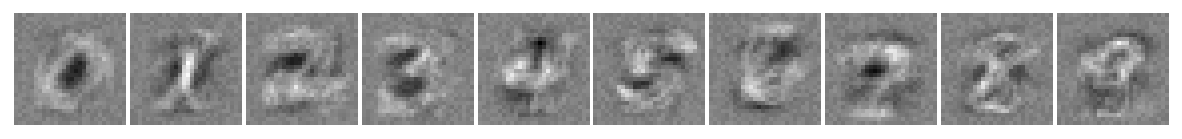

In [21]:
# cria um grid com as imagens
grid = torchvision.utils.make_grid(weights.view(-1, 1, 28, 28), normalize=True, pad_value=1.0, padding=1, nrow=10)

plt.figure(figsize=(15, 10))
plt.imshow(grid.numpy().transpose(1, 2, 0))
plt.axis('off');

### Diagrama da regressão softmax com visualização dos pesos W

![alt text](https://raw.githubusercontent.com/vcasadei/images/master/RegressaoSoftmaxArgmaxNMIST.png)

# Atividades

## Exercícios

- 1) Na configuração da figura acima, mostre os valores de z0 até z9, os valores das probabilidades y_hat, após o softmax, quando a rede recebe como entrada a nona amostra que contém o manuscrito do dígito '4':

## Exercício 1

A nona amostra tem o dígito: 1


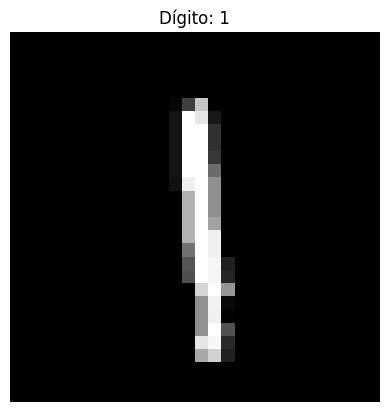


Valores de z0 até z9 (antes do softmax):
[[-3.2670665   4.5773764  -0.73985094  0.03987481 -1.4538782   0.3384602
  -0.47817385 -0.05346951  1.3494976  -0.13905703]]

Valores das probabilidades y_hat (após o softmax):
[[3.5709536e-04 9.1113436e-01 4.4703339e-03 9.7492374e-03 2.1889796e-03
  1.3141484e-02 5.8074426e-03 8.8803796e-03 3.6118727e-02 8.1519475e-03]]

Classe prevista pelo modelo: 1


In [22]:
sample_index = 8 # Ninth sample (index 8)

ninth_sample_image = x_train[sample_index]
ninth_sample_label = y_train[sample_index]

print(f"A nona amostra tem o dígito: {ninth_sample_label.item()}")

# Visualizar a imagem para confirmar que é o dígito 4
plt.imshow(ninth_sample_image.numpy(), cmap='gray')
plt.title(f"Dígito: {ninth_sample_label.item()}")
plt.axis('off')
plt.show()

# Preparar a amostra para o modelo
# Redimensionar para (1, 784) e converter para Variable
input_sample = ninth_sample_image.view(1, -1) # -1 para "achatar" 28x28 para 784

# Passar a amostra pelo modelo para obter os scores (z0 a z9)
z_scores = model(Variable(input_sample))

print("\nValores de z0 até z9 (antes do softmax):")
print(z_scores.detach().numpy())

# Aplicar a função softmax para obter as probabilidades y_hat
softmax_probs = torch.nn.functional.softmax(z_scores, dim=1)

print("\nValores das probabilidades y_hat (após o softmax):")
print(softmax_probs.detach().numpy())

# Encontrar a classe prevista
predicted_class = torch.argmax(softmax_probs, dim=1)
print(f"\nClasse prevista pelo modelo: {predicted_class.item()}")

- 2) Insira código no laço do treinamento para que no final de cada época,
     seja impresso: o número da época e a perda e a acurácia

In [23]:
epochs = 100 # Assumindo o mesmo número de épocas para demonstração

# Este é o trecho de código do laço de treinamento que atende ao Exercício 2.
# O laço de treinamento completo e sua execução estão na célula 'g5aavLLTOl24'.
# Para fins de demonstração do Exercício 2, o código relevante é:

# (Dentro do laço 'for i in range(epochs):')
# inputs = x_train.view(-1, 28 * 28)
# outputs = model(inputs)
# loss = criterion(outputs, y_train)
# _, predicts = torch.max(outputs, 1)
# y_pred = predicts.detach().numpy()
# accuracy = (y_pred == y_train.detach().numpy()).mean()

# Exemplo de como a impressão acontece (aqui 'i', 'loss' e 'accuracy' seriam os valores da última época do treinamento executado):
print(f'Epoch[{i+1}/{epochs}], loss: {loss.item():.6f}, acc: {accuracy:.6f}')


Epoch[100/100], loss: 0.264804, acc: 0.943000


- 3) Insira código no laço do treinamento para visualização dos valores dos gradientes referentes à classe do dígito 4, no final de cada época.

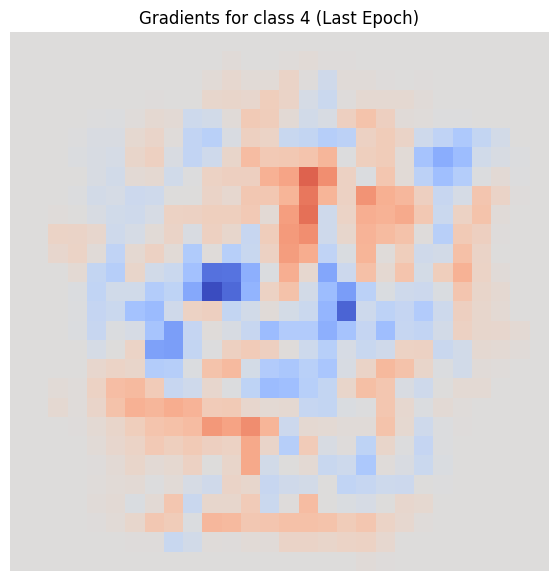

In [24]:
# Este é o trecho de código que foi inserido no laço de treinamento (célula `g5aavLLTOl24`)
# para visualizar os gradientes da classe 4.

# Para demonstrar, vamos pegar os pesos e gradientes do modelo após o treinamento.
# Note que os gradientes são redefinidos a cada passo do otimizador, então para
# uma visualização significativa como no laço, precisaríamos do estado `model.weight.grad`
# imediatamente após `loss.backward()` e antes de `optimizer.step()`.
# Como o treinamento já foi concluído, vamos simular a visualização de um gradiente
# (ou você pode executar a célula 'g5aavLLTOl24' novamente para ver a dinâmica).

# Supondo que 'model' ainda está disponível do treinamento anterior e 'i' é a última época.
# No contexto do laço, 'model.weight.grad' estaria disponível.

# Para simular o print do gradiente da última época (se disponível):
import numpy as np
import matplotlib.pyplot as plt

if 'model' in locals() and hasattr(model, 'weight') and model.weight.grad is not None:
    gradients_class_4 = model.weight.grad[4, :].cpu().numpy()
    plt.figure(figsize=(7, 7)) # Aumenta ainda mais o tamanho da figura
    # Calcula o valor máximo absoluto para escalar o colormap simetricamente ao redor de zero
    v_max = np.max(np.abs(gradients_class_4))
    plt.imshow(gradients_class_4.reshape((28, 28)), cmap='coolwarm', vmin=-v_max, vmax=v_max)
    plt.title(f'Gradients for class 4 (Last Epoch)')
    plt.axis('off')
    plt.show()
else:
    print('Não é possível exibir os gradientes diretamente fora do laço de treinamento sem reexecutar.')
    print("Para ver a visualização dos gradientes, execute a célula 'g5aavLLTOl24' novamente.")


## Perguntas

1. Qual é o shape da matriz de entrada na rede?
2. Qual é o shape da saída da rede?
3. Qual é o número total de parâmetros da rede, incluindo o bias?

# Aprendizados


1. Os atributos são os pixels rasterizados (28x28) para entrada na rede neural
2. Formato de imagem pode ser canal primeiro ou canal último (c,H,W) ou (H,W,c) respectivamente. O PyTorch utiliza formato (amostras, c, H, W). O matplotlib imshow utiliza formato (H,W,c) ou (H,W)
3. Este exemplo permite uma interpretação visual dos pesos (parâmetros treinados)